# Unsloth Fine-Tuning on CUDA

Fine-tune a Llama 3.2 model using Unsloth + LoRA on a CUDA GPU.

- Model loaded directly from Hugging Face via Unsloth's `FastLanguageModel`
- Dataset fetched directly from Hugging Face Hub
- All metrics logged to **TensorBoard**
- Requires CUDA GPU (Unsloth does not support CPU/MPS)


In [ ]:
# Install required packages (CUDA environment)
%pip install -q unsloth datasets trl tensorboard huggingface_hub seaborn


# Step 1: Load Model

Load `unsloth/Llama-3.2-3B` directly from Hugging Face using Unsloth's `FastLanguageModel`.
Unsloth automatically patches the model for 2x faster training with reduced VRAM usage.


In [ ]:
from unsloth import FastLanguageModel

HF_MODEL_ID = "unsloth/Llama-3.2-3B"
max_seq_length = 2048

base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=HF_MODEL_ID,
    max_seq_length=max_seq_length,
    dtype=None,          # auto-detect bfloat16 / float16
    load_in_4bit=False,   # 4-bit quantisation for lower VRAM
)

print(f"✓ Loaded: {HF_MODEL_ID}")
print(f"✓ Max sequence length: {max_seq_length}")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

# Step 2: Attach LoRA Adapters

Attach LoRA adapters using Unsloth's optimised `get_peft_model`. Only the adapter weights are trained, keeping VRAM usage low.

Parameters: rank=16, alpha=16.


In [ ]:
ft_model = FastLanguageModel.get_peft_model(
    base_model,
    r=16,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",  # saves extra VRAM
    random_state=3407,
)

trainable_params = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
print(f"✓ LoRA adapters attached")
print(f"✓ Trainable parameters: {trainable_params:,}")


Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


✓ LoRA adapters attached
✓ Trainable parameters: 24,313,856


# Step 3: Load Dataset

Load the `ServiceNow-AI/R1-Distill-SFT` dataset directly from Hugging Face Hub.
A subset of 5120 examples is used by default; adjust `subset_size` as needed.


In [ ]:
from datasets import load_dataset

HF_DATASET_ID = "ServiceNow-AI/R1-Distill-SFT"

dataset = load_dataset(HF_DATASET_ID, "v0", split="train")

# Use a subset for faster iteration; set to None to use the full dataset
subset_size = 10240
if subset_size and subset_size < len(dataset):
    dataset = dataset.select(range(subset_size))

print(f"✓ Dataset loaded: {len(dataset):,} examples")
print(f"✓ Columns: {dataset.column_names}")
print(f"\nSample problem snippet:\n{dataset[0].get('problem', '')[:300]}...")


✓ Dataset loaded: 10,240 examples
✓ Columns: ['id', 'reannotated_assistant_content', 'problem', 'source', 'solution', 'verified', 'quality_metrics']

Sample problem snippet:
There were 27 boys and 35 girls on the playground at recess. There were _____ children on the playground at recess....


# Step 4: Format Dataset

Apply the Llama 3.1 chat template to each example.
Each row is converted into a user/assistant conversation and tokenised to match inference-time format.


In [ ]:
from unsloth.chat_templates import get_chat_template

tokenizer = get_chat_template(tokenizer, chat_template="llama-3.1")

def formatting_prompts_func(examples):
    texts = []
    for problem, response in zip(examples["problem"], examples["reannotated_assistant_content"]):
        convo = [
            {"role": "user", "content": problem},
            {"role": "assistant", "content": response},
        ]
        texts.append(tokenizer.apply_chat_template(convo, tokenize=False, add_generation_prompt=False))
    return {"text": texts}

dataset = dataset.map(formatting_prompts_func, batched=True)

print("✓ Dataset formatted with chat template")
# print(f"\nFormatted example preview:\n{dataset[0]['text'][:300]}...")


✓ Dataset formatted with chat template


# Step 4a: Exploratory Data Analysis

Quick inspection of the formatted dataset before training:

1. **Sample comparison** — raw vs formatted text for the first example
2. **Context length distribution** — token count of the full formatted prompt
3. **Response length distribution** — token count of the assistant reply only


RAW PROBLEM:
There were 27 boys and 35 girls on the playground at recess. There were _____ children on the playground at recess.

RAW RESPONSE:
<think>
First, I need to determine the total number of children on the playground by adding the number of boys and girls.

There are 27 boys and 35 girls.

Adding these together: 27 boys + 35 girls = 62 children.

Therefore, the total number of children on the playground is 62.
</think>

To find the total number of children on the playground, we simply add the number of boys and girls together.

\[
\text{Total children} = \text{Number of boys} + \text{Number of girls}
\]

Plugging in the given values:

\[
\text{Total children} = 27 \text{ boys} + 35 \text{ girls} = 62 \text{ children}
\]

**Final Answer:**

\[
\boxed{62}
\]

FORMATTED TEXT:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 July 2024

<|eot_id|><|start_header_id|>user<|end_header_id|>

There were 27 boys and 35 girl

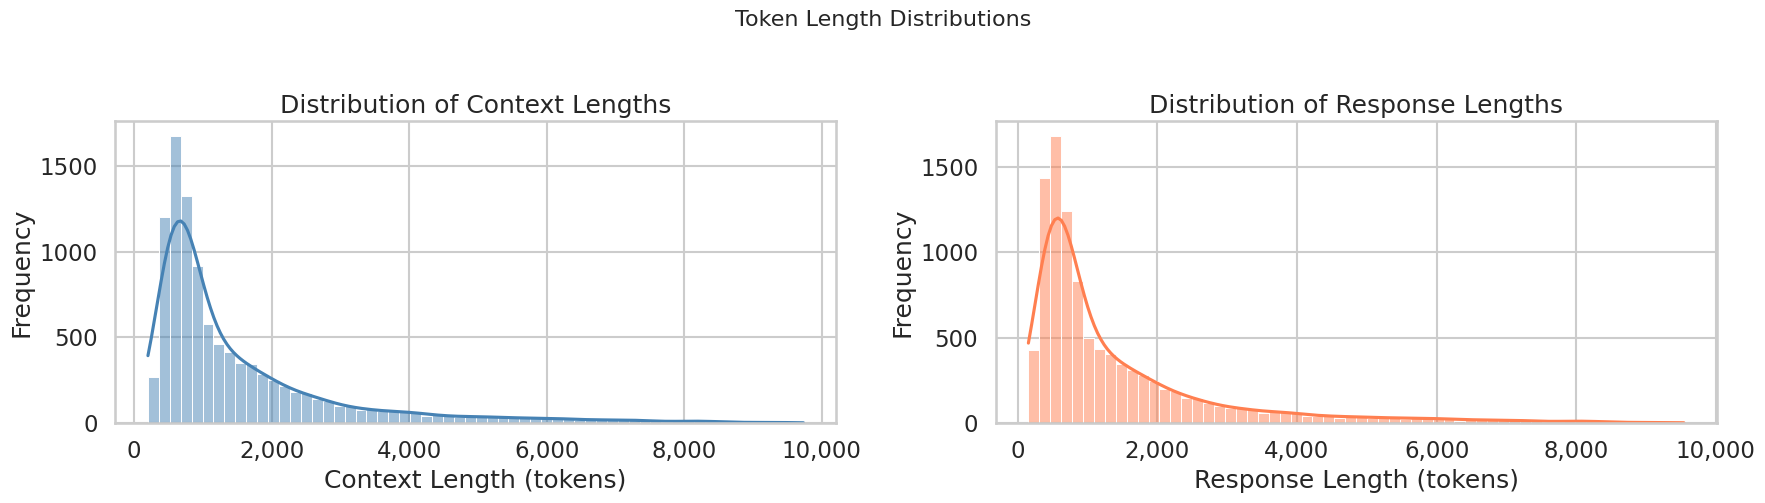

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sns.set_theme(style="whitegrid", context="talk", palette="muted")

# ── 1. Sample: raw vs formatted ──────────────────────────────────────────────
sample = dataset[0]
raw_problem = sample["problem"]
raw_response = sample["reannotated_assistant_content"]
formatted_text = sample["text"]

print("=" * 70)
print("RAW PROBLEM:")
print(raw_problem)
print("\nRAW RESPONSE:")
print(raw_response)
print("\n" + "=" * 70)
print("FORMATTED TEXT:")
print(formatted_text)
print("=" * 70)

# ── 2 & 3. Compute lengths ───────────────────────────────────────────────────
def token_len(text: str) -> int:
    return len(tokenizer.encode(text, add_special_tokens=False))

print("\nComputing token lengths (this may take ~1 min for 10k examples)...")

context_lengths = [token_len(row["text"]) for row in dataset]
response_lengths = [token_len(row["reannotated_assistant_content"]) for row in dataset]

df = pd.DataFrame({
    "context_length": context_lengths,
    "response_length": response_lengths,
})

print(f"✓ Done. Computed lengths for {len(df):,} examples.\n")
print(df[["context_length", "response_length"]].describe().round(1).to_string())

# ── 2. Context Length Distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(
    data=df,
    x="context_length",
    bins=60,
    kde=True,
    color="steelblue",
    ax=axes[0],
)
axes[0].set_title("Distribution of Context Lengths")
axes[0].set_xlabel("Context Length (tokens)")
axes[0].set_ylabel("Frequency")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# ── 3. Response Length Distribution ──────────────────────────────────────────
sns.histplot(
    data=df,
    x="response_length",
    bins=60,
    kde=True,
    color="coral",
    ax=axes[1],
)
axes[1].set_title("Distribution of Response Lengths")
axes[1].set_xlabel("Response Length (tokens)")
axes[1].set_ylabel("Frequency")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Token Length Distributions", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# Step 5: Configure Trainer

Configure TRL's `SFTTrainer`. Metrics are reported to **TensorBoard** (`./outputs/logs`).
Launch TensorBoard with: `tensorboard --logdir outputs/logs`


In [ ]:
from trl import SFTTrainer, SFTConfig
from transformers import TrainingArguments
from unsloth.chat_templates import train_on_responses_only
import torch

MAX_STEPS_QUICK_RUN = -1          # set to a positive number for a quick smoke-test
PER_DEVICE_TRAIN_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 4  # effective batch size = 8
WARMUP_STEPS = 10
NUM_TRAIN_EPOCHS = 3
LEARNING_RATE = 2e-4

trainer = SFTTrainer(
    model=ft_model,
    processing_class=tokenizer,
    train_dataset=dataset,
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    dataset_num_proc=2,
    packing=False,
    args=TrainingArguments(
        output_dir="outputs",
        per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        warmup_steps=WARMUP_STEPS,
        num_train_epochs=NUM_TRAIN_EPOCHS,
        max_steps=MAX_STEPS_QUICK_RUN,
        learning_rate=LEARNING_RATE,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=10,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=3407,
        report_to="tensorboard",
        logging_dir="outputs/logs",
    ),
)

# ── Prompt masking: only compute loss on assistant response tokens ────────────
# Tokens belonging to the user instruction are set to label=-100 so the model
# does NOT learn to predict them — only the assistant reply contributes to loss.
trainer = train_on_responses_only(
    trainer,
    instruction_part="<|start_header_id|>user<|end_header_id|>\n\n",
    response_part="<|start_header_id|>assistant<|end_header_id|>\n\n",
)

print("✓ Trainer configured with response-only loss (prompt tokens masked)")
print(f"✓ Reporting metrics to TensorBoard → ./outputs/logs")


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/10240 [00:00<?, ? examples/s]

Map (num_proc=16):   0%|          | 0/10240 [00:00<?, ? examples/s]

Filter (num_proc=16):   0%|          | 0/10240 [00:00<?, ? examples/s]

Unsloth: Removed 1 out of 10240 samples from train_dataset where all labels were -100 (no response found after truncation). This prevents NaN loss during training.
✓ Trainer configured with response-only loss (prompt tokens masked)
✓ Reporting metrics to TensorBoard → ./outputs/logs


# Step 6: Train the Model

VRAM stats are printed before training starts. All metrics (loss, learning rate, throughput) are written to TensorBoard in real time.


In [8]:
import torch

gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024**3, 3)
max_memory = round(gpu_stats.total_memory / 1024**3, 3)
print(f"Device: {gpu_stats.name}  |  Total VRAM: {max_memory} GB  |  Reserved before training: {start_gpu_memory} GB\n")

trainer_stats = trainer.train()

used_memory = round(torch.cuda.max_memory_reserved() / 1024**3, 3)
print(f"\n✓ Training complete!")
print(f"Final loss:       {trainer_stats.training_loss:.4f}")
print(f"Peak VRAM:        {used_memory} GB ({round(used_memory / max_memory * 100, 1)}% of {max_memory} GB)")
print(f"Training delta:   {round(used_memory - start_gpu_memory, 3)} GB")
print(f"\nView metrics:  tensorboard --logdir runs")


Device: NVIDIA L4  |  Total VRAM: 22.034 GB  |  Reserved before training: 6.146 GB



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 10,239 | Num Epochs = 3 | Total steps = 1,920
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
10,0.833780
20,0.688269
30,0.613909
40,0.588409
50,0.550265
60,0.550444
70,0.548642
80,0.548237
90,0.514152
100,0.512627


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-500/tokenizer_config.json.


Step,Training Loss
10,0.833780
20,0.688269
30,0.613909
40,0.588409
50,0.550265
60,0.550444
70,0.548642
80,0.548237
90,0.514152
100,0.512627


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-1000/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-1500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-1920/tokenizer_config.json.



✓ Training complete!
Final loss:       0.4196
Peak VRAM:        17.121 GB (77.7% of 22.034 GB)
Training delta:   10.975 GB

View metrics:  tensorboard --logdir runs


# Step 7: Inference Sanity Check

Switch the model to inference mode and run a quick reasoning prompt to verify the fine-tuned weights.


In [9]:
from unsloth import FastLanguageModel
from transformers import TextStreamer

FastLanguageModel.for_inference(ft_model)

test_problem = (
    "If Alex is taller than Blake, Blake is taller than Casey, "
    "and Casey is taller than Dana, who is the shortest person?"
)

messages = [{"role": "user", "content": test_problem}]
inputs = tokenizer.apply_chat_template(
    messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
).to("cuda")

text_streamer = TextStreamer(tokenizer, skip_prompt=True)
_ = ft_model.generate(
    input_ids=inputs,
    streamer=text_streamer,
    max_new_tokens=512,
    use_cache=True,
    temperature=0.6,
    top_p=0.9,
)


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn

<think>
First, I need to determine the heights of each person based on the given relationships.

1. Alex is taller than Blake.
   - Since Alex is taller than Blake, Alex must be taller than Blake.

2. Blake is taller than Casey.
   - Since Blake is taller than Casey, Blake must be taller than Casey.

3. Casey is taller than Dana.
   - Since Casey is taller than Dana, Casey must be taller than Dana.

From the above, I can see that Alex is taller than Blake, Blake is taller than Casey, and Casey is taller than Dana. This means that Alex is taller than Casey, and Blake is taller than Dana.

To find the shortest person, I need to compare the heights of Alex, Blake, and Dana. Since Alex is taller than Blake, and Blake is taller than Dana, the shortest person must be Dana.

Therefore, Dana is the shortest person.
</think>

To determine who is the shortest person, let's analyze the given relationships step by step.

1. **Alex is taller than Blake:**
   - This means that Alex is taller than Bl

# Step 8: Save Artifacts

Save the LoRA adapter weights locally. Optionally push to the Hugging Face Hub or export to GGUF.


In [11]:
ft_model.save_pretrained("outputs/adapters/")
tokenizer.save_pretrained("outputs/adapters/")
print("✓ LoRA adapters saved to ./outputs/adapters/")

from huggingface_hub import notebook_login, hf_api
notebook_login()

# Optional: push to Hugging Face Hub
ft_model.push_to_hub("tangowhisky16/llama-3.2-3B-think-fp16")
tokenizer.push_to_hub("tangowhisky16/llama-3.2-3B-think-fp16")

# ── Save full fused model (merged base + adapters) ───────────────────────────
# Merges LoRA weights into the base model and saves in float16.
# This produces a standalone model that can be loaded without PEFT/Unsloth.
ft_model.save_pretrained_merged(
    "outputs/fused_model",
    tokenizer,
    save_method="merged_16bit",   # options: "merged_16bit" | "merged_4bit" | "lora"
)
print("✓ Fused model saved to outputs/fused_model")

# Optional: push fused model to Hugging Face Hub
# model.push_to_hub_merged("tangowhisky16/llama-3.2-3B-think", tokenizer, save_method="merged_4bit")

hf_api.upload_folder(
    folder_path="outputs",
    repo_id="tangowhisky16/llama-3.2-3B-think-fp16",
    repo_type="model"
)

# Optional: export to GGUF (requires llama.cpp)
# ft_model.save_pretrained_gguf("outputs/lora_model_gguf", tokenizer, quantization_method="q4_k_m")


✓ LoRA adapters saved to ./outputs/adapters/


README.md:   0%|          | 0.00/535 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 45.8kB / 97.3MB            

...

  ...ckpoint-30/tokenizer.json: 100%|##########| 17.2MB / 17.2MB            

  ...adapter_model.safetensors:   0%|          | 45.8kB / 97.3MB            

  ...adapter_model.safetensors:   0%|          | 45.8kB / 97.3MB            

  ...adapter_model.safetensors:  74%|#######3  | 72.0MB / 97.3MB            

CommitInfo(commit_url='https://huggingface.co/tangowhisky16/llama-3.2-3B-think-fp16/commit/e2888c33de1fc6b2e36ff5bc0748fb3a936ca171', commit_message='Upload folder using huggingface_hub', commit_description='', oid='e2888c33de1fc6b2e36ff5bc0748fb3a936ca171', pr_url=None, repo_url=RepoUrl('https://huggingface.co/tangowhisky16/llama-3.2-3B-think-fp16', endpoint='https://huggingface.co', repo_type='model', repo_id='tangowhisky16/llama-3.2-3B-think-fp16'), pr_revision=None, pr_num=None)